# Book Recommendation System

## Introduction
This project explores a dataset of books and builds a simple **content-based recommendation system**. Given a book title, the system finds other books with similar titles and authors using **TF-IDF** and **Nearest Neighbors**. We also identify popular, highly rated books.

**Goal:** Explore the data, find popular books, and recommend similar books.

**Limitation:** This dataset has no user reading history, descriptions, or genres. Therefore, these are metadata-based similarity recommendations, not personalized recommendations.

**Data Dictionary**

| Column | Description |
|---|---|
| `bookID` | Book identifier |
| `title` | Book title |
| `authors` | Author name(s) |
| `average_rating` | Average reader rating (0–5) |
| `ratings_count` | Number of reader ratings |
| `language_code` | Language of the book |
| `  num_pages` | Number of pages (original CSV column name contains spaces) |

### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

### 2. Load the Dataset
Read the CSV file. A small number of malformed source rows may be skipped

In [2]:
df = pd.read_csv('books.csv', on_bad_lines='skip')

In [3]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


### 3. Exploratory Data Analysis (EDA)

In [4]:
df.shape

(11123, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  str    
 2   authors             11123 non-null  str    
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  str    
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  str    
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  str    
 11  publisher           11123 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 2.1 MB


In [6]:
df.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

In [7]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


### Average Book Ratings

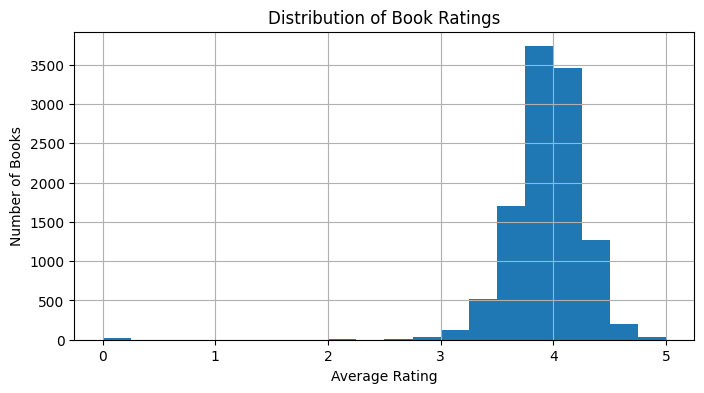

In [8]:
df['average_rating'].hist(bins=20, figsize=(8, 4))
plt.title('Distribution of Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.show()

### Number of Ratings
Most books receive relatively few ratings. A log scale helps show the distribution

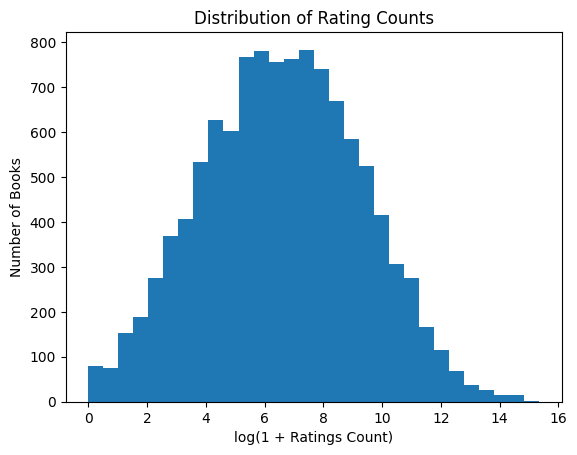

In [9]:
import numpy as np
plt.hist(np.log1p(df['ratings_count']), bins=30)
plt.title('Distribution of Rating Counts')
plt.xlabel('log(1 + Ratings Count)')
plt.ylabel('Number of Books')
plt.show();

### 4. Data Preparation
Keep the columns needed for recommendations and remove records without a title or author

In [10]:
books = df[['bookID', 'title', 'authors', 'average_rating', 'ratings_count']].dropna().copy()

In [11]:
books = books.drop_duplicates(subset='bookID').reset_index(drop=True)

In [12]:
books.shape

(11123, 5)

### 5. Popular Books
A high rating based on only a few votes can be misleading. Here, we require at least **1,000 ratings** before sorting books by average rating. This is a simple filter, not a personalized model

In [13]:
popular = books[books['ratings_count'] >= 1000].sort_values(['average_rating', 'ratings_count'], ascending=False).head(10)

In [14]:
popular[['title', 'authors', 'average_rating', 'ratings_count']]

,title,authors,average_rating,ratings_count
6587,The Complete Calvin and Hobbes,Bill Watterson,4.82,32213
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428
6589,It's a Magical World (Calvin and Hobbes #11),Bill Watterson,4.76,23875
6,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,28242
6590,Homicidal Psycho Jungle Cat (Calvin and Hobbes...,Bill Watterson,4.72,15365
6593,Calvin and Hobbes: Sunday Pages 1985-1995: An ...,Bill Watterson,4.71,3613
5614,Study Bible: NIV,Anonymous,4.70,4166
6497,The Complete Aubrey/Maturin Novels (5 Volumes),Patrick O'Brian,4.70,1338
6591,The Days Are Just Packed,Bill Watterson,4.69,20308
1530,The Life and Times of Scrooge McDuck,Don Rosa,4.67,2467


### Top 10 Popular Books
Visualize the highest-rated books with at least 1,000 ratings

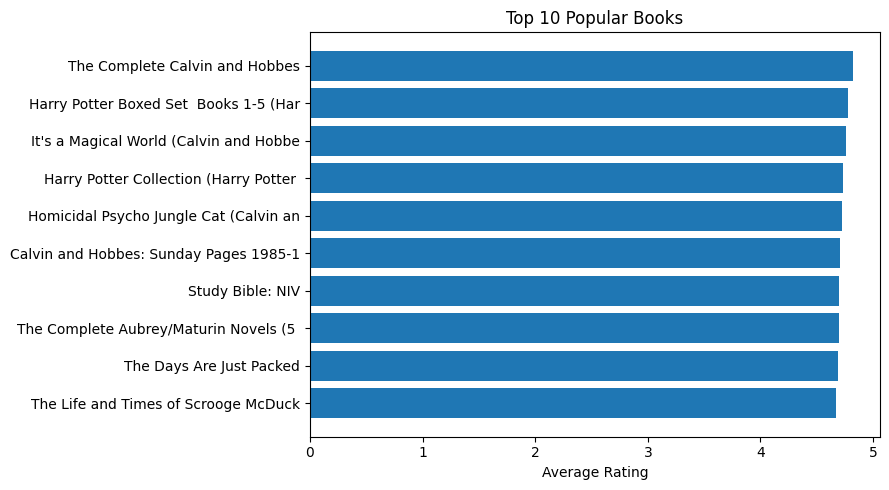

In [24]:
plt.figure(figsize=(9, 5))
plt.barh(popular['title'].str.slice(0, 38)[::-1], popular['average_rating'][::-1])
plt.xlabel('Average Rating')
plt.title('Top 10 Popular Books')
plt.tight_layout()
plt.show()

### 6. Build the Recommendation Model
Combine book titles and author names into text. **TF-IDF** converts the text into numeric features. **Nearest Neighbors** then finds the closest matching books using cosine distance

In [16]:
books['content'] = books['title'].str.lower() + ' ' + books['authors'].str.lower()

In [17]:
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(books['content'])

In [18]:
model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(features)

,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


### 7. Recommend Similar Books
Return similar books with a cosine similarity score (0–1). Duplicate titles are excluded so different editions of the same book are not recommended

In [19]:
def recommend_books(title, n=5):
    matches = books[books['title'].str.contains(title, case=False, regex=False, na=False)]
    if matches.empty:
        return 'Book not found. Try another title.'

    index = matches.index[0]
    distances, indices = model.kneighbors(features[index], n_neighbors=min(100, len(books)))
    results = books.iloc[indices[0]].copy()
    results['similarity_score'] = (1 - distances[0]).round(3)
    results = results[results.index != index]
    results = results[results['title'].str.casefold() != books.loc[index, 'title'].casefold()]
    results = results.drop_duplicates(subset='title').head(n)
    return results[['title', 'authors', 'average_rating', 'similarity_score']].reset_index(drop=True)

In [20]:
recommend_books('Harry Potter and the Half-Blood Prince')

,title,authors,average_rating,similarity_score
0,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling/Mary GrandPré,4.42,0.768
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0.768
2,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling/Mary GrandPré,4.47,0.764
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,0.752
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0.750


In [21]:
recommend_books('The Hobbit')

,title,authors,average_rating,similarity_score
0,The Lord of the Rings / The Hobbit,J.R.R. Tolkien,4.59,0.772
1,The Lord of the Rings Millennium Edition Boxed...,J.R.R. Tolkien,4.50,0.688
2,The Hobbit or There and Back Again,J.R.R. Tolkien,4.27,0.653
3,The Hobbit,J.R.R. Tolkien,4.27,0.653
4,The Hobbit: Or There and Back Again,J.R.R. Tolkien,4.27,0.653


### 8. Quick Checks
Verify five recommendations, unique recommended titles, and the message for unknown books

In [22]:
results = recommend_books('The Hobbit')
assert len(results) == 5
assert results['title'].is_unique
assert 'Book not found' in recommend_books('This Title Does Not Exist')
print('Basic checks passed.')

Basic checks passed.


## Conclusion
We explored 11,123 books, visualized ratings and popularity, and built a simple content-based recommender with TF-IDF and KNN. We also removed exact duplicate titles from the recommendation list and displayed cosine similarity scores.

**Limitations:** Similarity scores measure title/author text overlap, not reader satisfaction. Books in the same series may dominate recommendations. Genre, descriptions, and user–book ratings would be necessary to build and evaluate more relevant or personalized recommendations.